# Week 2 — Block 2: Guided Demo (Grammar & Design)

**DATS 6401 · Visualization of Complex Data**

~25 min. One relationship — *do tips scale with bills, and does day matter?* — encoded four ways, then the grammar made executable in Altair.

1. Four encodings of one question (~12 min)
2. Altair: the grammar as an API (~8 min)
3. Faceting (~5 min)

In [4]:
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

tips = px.data.tips()
tips.head(3)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


## Part 1 — Four encodings of one question

**Encoding 1 — position only.** The relationship, nothing else.

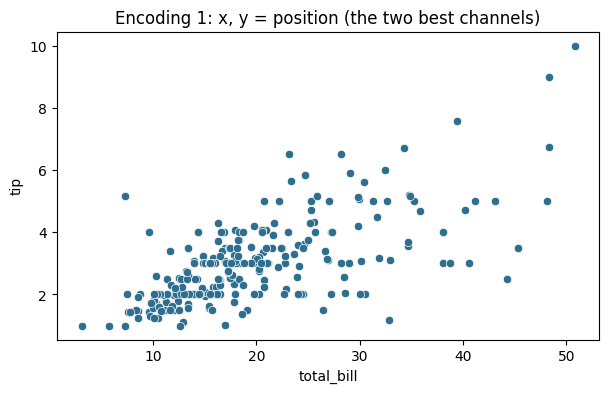

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(data=tips, x="total_bill", y="tip", ax=ax, color="#2E6E8E")
ax.set_title("Encoding 1: x, y = position (the two best channels)")
plt.show()

**Encoding 2 — add hue for day.** A categorical variable on an identity channel — expressiveness ✓.

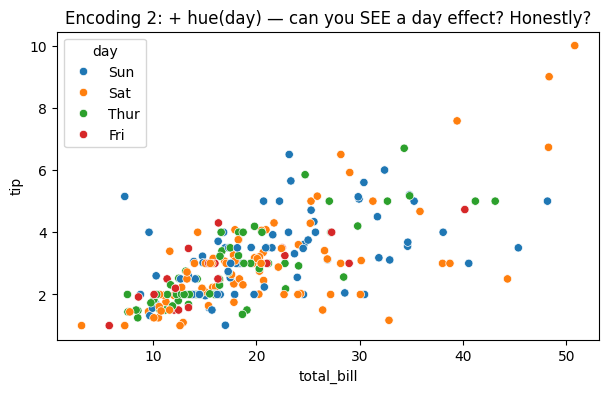

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="day", ax=ax)
ax.set_title("Encoding 2: + hue(day) — can you SEE a day effect? Honestly?")
plt.show()

**Narrate:** four overlapping hues — the day signal is murky. Not because there's no effect, but because hue is a weak channel for this many overlapping groups. Hold that thought for faceting.

**Encoding 3 — the comparison on position.** If the *question* is "which day tips most," put DAY on position:

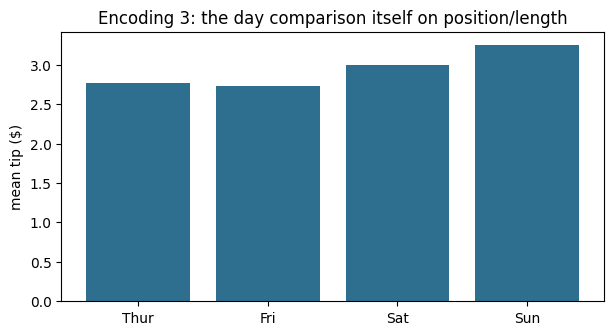

In [10]:
day_means = tips.groupby("day", as_index=False)["tip"].mean()
order = ["Thur", "Fri", "Sat", "Sun"]
day_means = day_means.set_index("day").loc[order].reset_index()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(day_means["day"], day_means["tip"], color="#2E6E8E")
ax.set_ylabel("mean tip ($)")
ax.set_title("Encoding 3: the day comparison itself on position/length")
plt.show()

**Encoding 4 — the same comparison on area (deliberately worse):**

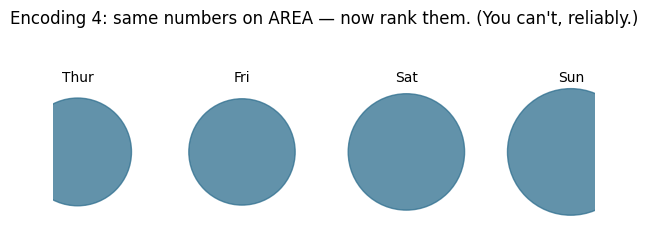

In [11]:
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.scatter(range(4), [1]*4, s=(day_means["tip"]*28)**2, color="#2E6E8E", alpha=0.75)
for i, d in enumerate(day_means["day"]):
    ax.annotate(d, (i, 1.35), ha="center")
ax.set_ylim(0.6, 1.6); ax.axis("off")
ax.set_title("Encoding 4: same numbers on AREA — now rank them. (You can't, reliably.)")
plt.show()

**Ask the room:** which day is 2nd? On the bars you answered instantly; here you're guessing. That gap *is* the Cleveland–McGill ranking, lived.

## Part 2 — The grammar as an API (Altair)

In [13]:
import altair as alt

chart = (alt.Chart(tips)
    .mark_point()
    .encode(
        x="total_bill",
        y="tip",
        color="day",     # identity channel <- categorical ✓
        shape="time",    # identity channel <- categorical ✓
    ))
chart.interactive()

alt.Chart(...)

**Narrate the mapping out loud:** *mark_point, x position gets total_bill, hue gets day…* — the API forces you to SAY the encoding, which is exactly the discipline.

## Part 3 — Faceting: position for categories

In [14]:
(alt.Chart(tips)
    .mark_point(opacity=0.6)
    .encode(x="total_bill", y="tip", color="day")
    .facet(column="time"))

alt.FacetChart(...)

Compare to Encoding 2: the murky hue-only chart vs. panels. **Same scales across panels = honest comparison.** And the murk has a name now: when hue saturates, give the category position — a panel.

## Wrap-up → Block 3

You saw one question, four encodings, two readable. Block 3: **you** pick a question, build three encodings, and defend the channels — side by side in Streamlit columns.